In [236]:
import torch
from torch import nn
from jaxtyping import Float

In [237]:
def make_gaussian_data(mean: tuple[float, float], count: int, std: float, label: int) -> Float[torch.Tensor, "count 3"]:
    mean_tensor = torch.tensor(mean)
    gaussian = torch.randn(count, 2) * std + mean_tensor
    labels = torch.full((count, 1), label)
    return torch.cat([gaussian, labels], dim=1)

cluster_1 = make_gaussian_data((1, 1), 200, 1.0, 0)
cluster_2 = make_gaussian_data((-1, -1), 200, 1.0, 1)

data = torch.cat([cluster_1, cluster_2], dim=0)

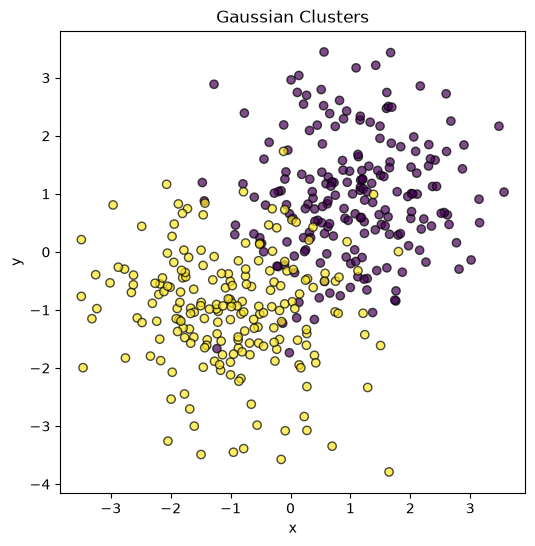

In [238]:
import matplotlib.pyplot as plt

data_np = data.numpy()

plt.figure(figsize=(6, 6))
plt.scatter(data_np[:, 0], data_np[:, 1], c=data_np[:, 2], alpha=0.7, edgecolors="k")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Gaussian Clusters")
plt.show()

In [ ]:
class MLP(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.fc1 = nn.Linear(2, 16)
        self.fc2 = nn.Linear(16, 2)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x
    
model = MLP()
output = model(torch.randn(1,2))
output

tensor([[ 0.1127, -0.1617]], grad_fn=<AddmmBackward0>)

In [240]:
def train(model, X, y, criterion, epochs=1000, lr=0.1):
    optimiser = torch.optim.SGD(model.parameters(), lr=lr)
    for epoch in range(epochs):
        optimiser.zero_grad()
        output = model(X)
        criterion = nn.CrossEntropyLoss()
        loss = criterion(output, y)
        loss.backward()
        optimiser.step()
        if epoch % 20 == 0:
            print(loss.item())

X = data[:, :2]
y = data[:, 2].long()
criterion = nn.CrossEntropyLoss()
train(model, X, y, criterion)

0.8043988943099976
0.26488393545150757
0.23458796739578247
0.22901448607444763
0.227390855550766
0.22665062546730042
0.22614909708499908
0.22573424875736237
0.2253638058900833
0.22502802312374115
0.22471286356449127
0.22441677749156952
0.2241443246603012
0.22389015555381775
0.22364002466201782
0.22336620092391968
0.2231157273054123
0.22286978363990784
0.22259873151779175
0.22231729328632355
0.22203943133354187
0.22178798913955688
0.22154971957206726
0.22128577530384064
0.22103528678417206
0.2208050787448883
0.2205793261528015
0.22037671506404877
0.2201692759990692
0.21997293829917908
0.21976238489151
0.2195395976305008
0.2193307727575302
0.2191285640001297
0.2189267873764038
0.21873816847801208
0.21855396032333374
0.21838213503360748
0.21822717785835266
0.21807527542114258
0.21792690455913544
0.21777793765068054
0.21763421595096588
0.21749232709407806
0.21735116839408875
0.2172136753797531
0.21707795560359955
0.2169436514377594
0.21681219339370728
0.21668070554733276


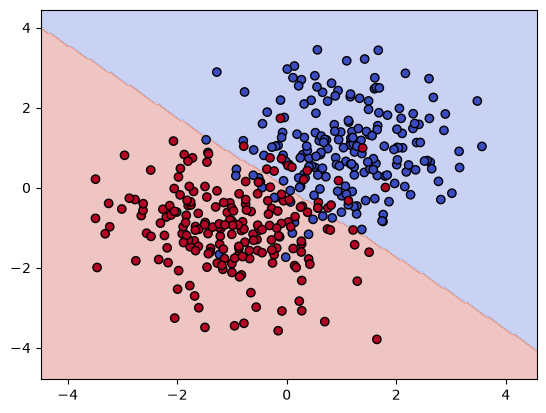

tensor([[1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]])

In [241]:
def decision_boundary(model, steps):
    x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
    y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1

    x_vals = torch.linspace(x_min, x_max, steps)
    y_vals = torch.linspace(y_min, y_max, steps)
    xx, yy = torch.meshgrid(x_vals, y_vals, indexing='xy')
    grid = torch.stack([xx.flatten(), yy.flatten()], dim=1)

    model.eval()
    with torch.no_grad():
        preds = model(grid).argmax(dim=1) 

    preds = preds.reshape(xx.shape)

    plt.contourf(xx.numpy(), yy.numpy(), preds.numpy(), alpha=0.3, cmap='coolwarm')
    plt.scatter(data[:, 0], data[:, 1], c=data_np[:, 2], cmap='coolwarm', edgecolors='k')
    plt.show()

    return preds


decision_boundary(model, 200)